In [ ]:
(* ID linear model utilities: transport matrix exponential representation, parametric model and linear optics distortion *)
(* I.M., 2025-2026 *)

# Transport matrix (exponential representation)

In [1]:
(* A generic linear symplectic transport matrix can be represented in exponential form as exp(S A) *)
(* Here, S is the standard symplectic matrix (skew-symmetric with S^2 = -I), and A is an arbitrary symmetric matrix *)
(* Since A is symmetric, it has ten independent parameters in 4D transverse phase space, which fully specify it *)
(* The matrix A is also related to the time-one Hamiltonian H = 1/2 x^T A x, with x = (q_x, p_x, q_y, p_y) *)
(* In general, this Hamiltonian is a linear combination of ten second-degree monomials with ten independent coefficients (twiss parameters) *)
(* Without coupling, A has a block-diagonal form and can be specified by only three parameters in each transverse plane *)
(* In this section correspondence between transport matrix exponent and the actual transport matrix are explored *)

0    1   0    0

-1   0   0    0

0    0   0    1

0    0   -1   0
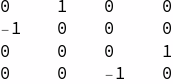

In [8]:
(* skew symplectic identity matrix *)

S = {{0, 1, 0, 0}, {-1, 0, 0, 0}, {0, 0, 0, 1}, {0, 0, -1, 0}} ;
S // TableForm

0   0   0   0

0   a   0   0

0   0   0   0

0   0   0   b
1   a   0   0

0   1   0   0

0   0   1   b

0   0   0   1
    2       2
a px    b py
----- + -----
  2       2
{a px + qx, px, b py + qy, py}
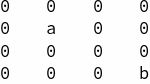
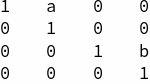
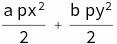

In [11]:
(* drift-like transport matrix exponent *)

A = {{0, 0, 0, 0}, {0, a, 0, 0}, {0, 0, 0, 0}, {0, 0, 0, b}} ;
M = MatrixExp[S . A] ;
H = 1/2 {qx, px, qy, py} . A . {qx, px, qy, py} // Expand ;

A // TableForm
M // TableForm
H
M . {qx, px, qy, py}

a   0   0   0

0   0   0   0

0   0   b   0

0   0   0   0
1    0   0    0

-a   1   0    0

0    0   1    0

0    0   -b   1
    2       2
a qx    b qy
----- + -----
  2       2
{qx, px - a qx, qy, py - b qy}
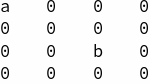
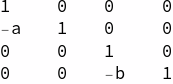
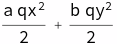

In [19]:
(* kick-like matrix exponent *)

A = {{a, 0, 0, 0}, {0, 0, 0, 0}, {0, 0, b, 0}, {0, 0, 0, 0}} ;
M = MatrixExp[S . A] ;
H = 1/2 {qx, px, qy, py} . A . {qx, px, qy, py} // Expand ;

A // TableForm
M // TableForm
H
M . {qx, px, qy, py}

a   0   0   0

0   b   0   0

0   0   c   0

0   0   0   d
                                  Sqrt[b] Sin[Sqrt[a] Sqrt[b]]
                                  ----------------------------
Cos[Sqrt[a] Sqrt[b]]                        Sqrt[a]
 


>    0                                 0

  Sqrt[a] Sin[Sqrt[a] Sqrt[b]]
-(----------------------------)
            Sqrt[b]               Cos[Sqrt[a] Sqrt[b]]
 


>    0                                 0



0                                 0
 
                                       Sqrt[d] Sin[Sqrt[c] Sqrt[d]]
                                       ----------------------------
>    Cos[Sqrt[c] Sqrt[d]]                        Sqrt[c]



0                                 0
 
       Sqrt[c] Sin[Sqrt[c] Sqrt[d]]
     -(----------------------------)
>                Sqrt[d]               Cos[Sqrt[c] Sqrt[d]]
    2       2       2       2
b px    d py    a qx    c qy
----- + ----- + ----- + -----
  2       2       2       2
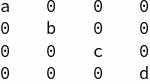
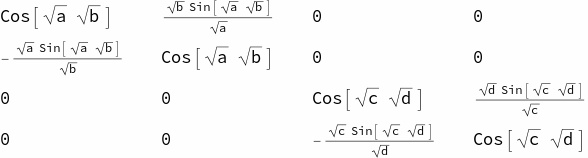
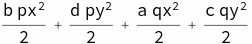

In [27]:
(* quadrupole-like matrix exponent (generic independent focusing) *)

A = {{a, 0, 0, 0}, {0, b, 0, 0}, {0, 0, c, 0}, {0, 0, 0, d}} ;
M = MatrixExp[S . A] // ExpToTrig // Simplify ;
H = 1/2 {qx, px, qy, py} . A . {qx, px, qy, py} // Expand ;

A // TableForm
M // TableForm
H

ax   bx   0    0

bx   cx   0    0

0    0    ay   by

0    0    by   cy
                                         2
            2             bx Sinh[Sqrt[bx  - ax cx]]
Cosh[Sqrt[bx  - ax cx]] + --------------------------
                                     2
                              Sqrt[bx  - ax cx]
 
                    2
     cx Sinh[Sqrt[bx  - ax cx]]
     --------------------------
                2
>        Sqrt[bx  - ax cx]
 




>    0
 




>    0

                 2
  ax Sinh[Sqrt[bx  - ax cx]]
-(--------------------------)
             2
      Sqrt[bx  - ax cx]
 
                                              2
                 2             bx Sinh[Sqrt[bx  - ax cx]]
     Cosh[Sqrt[bx  - ax cx]] - --------------------------
                                          2
>                                  Sqrt[bx  - ax cx]
 




>    0
 




>    0





0
 




>    0
 
                                              2
                 2             by Sinh[Sqrt[by  - ay cy]]
     Cosh[Sqrt[by  - ay cy]] + --------------------------
                                          2
>                                  Sqrt[by  - ay cy]
 
                    2
     cy Sinh[Sqrt[by  - ay cy]]
     --------------------------
                2
>        Sqrt[by  - ay cy]





0
 




>    0
 
                      2
       ay Sinh[Sqrt[by  - ay cy]]
     -(--------------------------)
                  2
>          Sqrt[by  - ay cy]
 
                                              2
                 2             by Sinh[Sqrt[by  - ay cy]]
     Cosh[Sqrt[by  - ay cy]] - --------------------------
                                          2
>                                  Sqrt[by  - ay cy]
     2        2                   2                   2
cx px    cy py               ax qx               ay qy
------ + ------ + bx px qx + ------ + by py qy + ------
  2        2                   2                   2
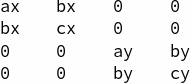
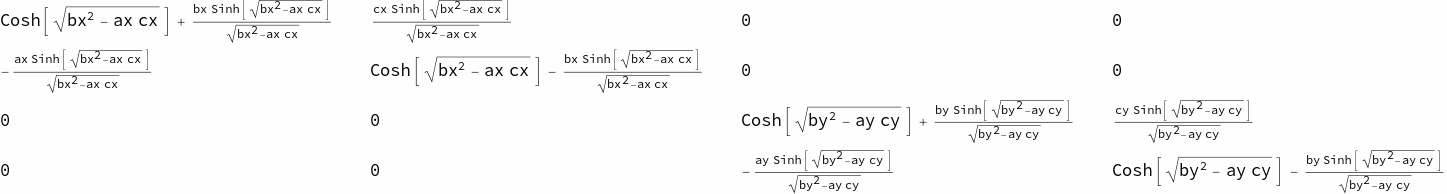
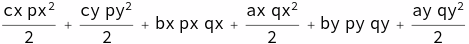

In [34]:
(* generic uncoupled matrix exponent (block form) *)

H = ax/2 qx^2 + bx qx px + cx/2 px^2 + ay/2 qy^2 + by qy py + cy/2 py^2 ;
A = D[H, {{qx, px, qy, py}, 1 + 1}] ;

M = MatrixExp[S . A] // ExpToTrig // Simplify ;
H = 1/2 {qx, px, qy, py} . A . {qx, px, qy, py} // Expand ;

A // TableForm
M // TableForm
H

0   0   a   0

0   0   0   b

a   0   0   0

0   b   0   0


Cos[Sqrt[a] Sqrt[b]]              0
 
                                       Sqrt[b] Sin[Sqrt[a] Sqrt[b]]
                                       ----------------------------
>    0                                           Sqrt[a]



0                                 Cos[Sqrt[a] Sqrt[b]]
 
       Sqrt[a] Sin[Sqrt[a] Sqrt[b]]
     -(----------------------------)
>                Sqrt[b]               0

                                  Sqrt[b] Sin[Sqrt[a] Sqrt[b]]
                                  ----------------------------
0                                           Sqrt[a]
 


>    Cos[Sqrt[a] Sqrt[b]]              0

  Sqrt[a] Sin[Sqrt[a] Sqrt[b]]
-(----------------------------)
            Sqrt[b]               0
 


>    0                                 Cos[Sqrt[a] Sqrt[b]]
b px py + a qx qy
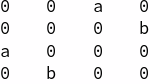
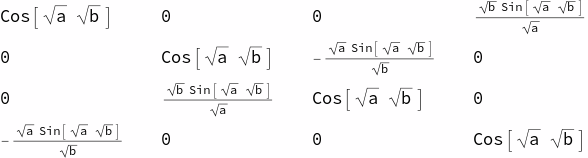

In [42]:
(* skew-like quadrupole matrix exponent (generic independent focusing) *)

H = a qx qy + b px py ;
A = D[H, {{qx, px, qy, py}, 1 + 1}] ;

M = MatrixExp[S . A] // ExpToTrig // Simplify ;
H = 1/2 {qx, px, qy, py} . A . {qx, px, qy, py} // Expand ;

A // TableForm
M // TableForm
H

0   0   0   a

0   0   b   0

0   b   0   0

a   0   0   0


Cosh[Sqrt[a] Sqrt[b]]           0
 
     Sqrt[b] Sinh[Sqrt[a] Sqrt[b]]
     -----------------------------
>               Sqrt[a]              0



0                               Cosh[Sqrt[a] Sqrt[b]]
 
                                       Sqrt[a] Sinh[Sqrt[a] Sqrt[b]]
                                     -(-----------------------------)
>    0                                            Sqrt[b]

Sqrt[a] Sinh[Sqrt[a] Sqrt[b]]
-----------------------------
           Sqrt[b]              0
 


>    Cosh[Sqrt[a] Sqrt[b]]           0

                                  Sqrt[b] Sinh[Sqrt[a] Sqrt[b]]
                                -(-----------------------------)
0                                            Sqrt[a]
 


>    0                               Cosh[Sqrt[a] Sqrt[b]]
a py qx + b px qy
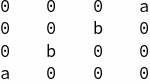
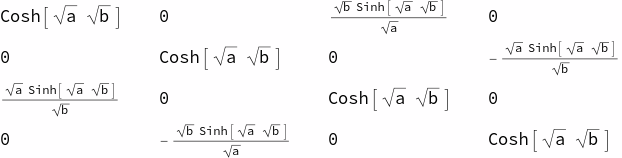

In [50]:
(* solenoid-like matrix exponent (generic independent focusing) *)

H = (a qx py + b px qy) ;
A = D[H, {{qx, px, qy, py}, 1 + 1}] ;

M = MatrixExp[S . A] // ExpToTrig // Simplify ;
H = 1/2 {qx, px, qy, py} . A . {qx, px, qy, py} // Simplify ;

A // TableForm
M // TableForm
H

2
2 (1 + ax ) nux Pi
------------------
        bx           2 ax nux Pi   0                    0

2 ax nux Pi          2 bx nux Pi   0                    0

                                            2
                                   2 (1 + ay ) nuy Pi
                                   ------------------
0                    0                     by           2 ay nuy Pi

0                    0             2 ay nuy Pi          2 by nuy Pi
                                     2    2
             2                (1 + ax ) qx
nux Pi (bx px  + 2 ax px qx + -------------) + 
                                   bx
 
                                         2    2
                 2                (1 + ay ) qy
>   nuy Pi (by py  + 2 ay py qy + -------------)
                                       by
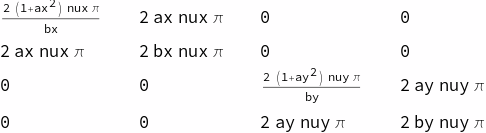
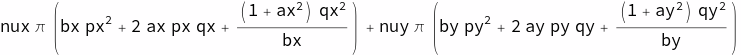

In [58]:
(* exponential representation of CS one-turn transport matrix *)

Clear[matrix] ;
matrix[{ax_, bx_, nux_}, {ay_, by_, nuy_}] := {
	{Cos[2 Pi nux] + ax Sin[2 Pi nux], bx Sin[2 Pi nux], 0, 0},
	{-(1 + ax^2)/bx Sin[2 Pi nux], Cos[2 Pi nux] - ax Sin[2 Pi nux], 0, 0},
	{0, 0, Cos[2 Pi nuy] + ay Sin[2 Pi nuy], by Sin[2 Pi nuy]},
	{0, 0, -(1 + ay^2)/by Sin[2 Pi nuy], Cos[2 Pi nuy] - ay Sin[2 Pi nuy]}
} ;

A = FullSimplify[-S . MatrixLog[matrix[{ax, bx, nux}, {ay, by, nuy}]], Assumptions -> {bx > 0, by > 0, 0 < nux < 1/2, 0 < nuy < 1/2}] ;

A // TableForm
H = 1/2 {qx, px, qy, py} . A . {qx, px, qy, py} ;
H = Collect[H, {nux, nuy}, Simplify]

kq L   0   0         0

0      L   0         0

0      0   -(kq L)   0

0      0   0         L
     2     2         2     2
L (px  + py  + kq (qx  - qy ))
------------------------------
              2
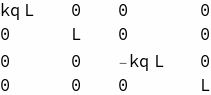
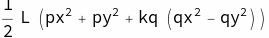

In [65]:
(* exponential representation of normal quadrupole transport matrix *)

Clear[matrix] ;
matrix[k_, l_] := {
    {Cos[Sqrt[k]*l], Sin[Sqrt[k]*l]/Sqrt[k], 0, 0},
    {-(Sqrt[k]*Sin[Sqrt[k]*l]), Cos[Sqrt[k]*l], 0, 0}, 
    {0, 0, Cosh[Sqrt[k]*l], Sinh[Sqrt[k]*l]/Sqrt[k]}, 
    {0, 0, Sqrt[k]*Sinh[Sqrt[k]*l], Cosh[Sqrt[k]*l]}
} ;

A = PowerExpand[FullSimplify[-S . MatrixLog[matrix[kq, L]], Assumptions -> {kq > 0, L > 0}]] ;

A // TableForm
H = 1/2 {qx, px, qy, py} . A . {qx, px, qy, py} ;
H = Collect[H, {nux, nuy}, Simplify]

2     2
L (px  + py )
-------------
      2
0   0   0   0

0   L   0   0

0   0   0   0

0   0   0   L
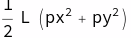
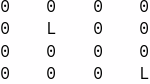

In [72]:
(* drift hamiltonian *)

H = L 1/2 (px^2 + py^2)
A = D[H, {{qx, px, qy, py}, 1 + 1}] ;
A // TableForm

2     2         2     2
   px  + py    kn (qx  - qy )
L (--------- + --------------)
       2             2
kn L   0   0         0

0      L   0         0

0      0   -(kn L)   0

0      0   0         L
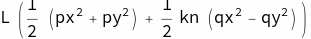
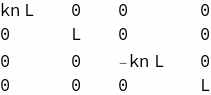

In [76]:
(* quadrupole hamiltonian *)

H = L (1/2 (px^2 + py^2) + 1/2 kn (qx^2 - qy^2))
A = D[H, {{qx, px, qy, py}, 1 + 1}] ;
A // TableForm

2     2                    2     2
   px  + py               kn (qx  - qy )
L (--------- - ks qx qy + --------------)
       2                        2
kn L      0   -(ks L)   0

0         L   0         0

-(ks L)   0   -(kn L)   0

0         0   0         L
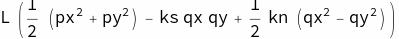
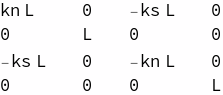

In [80]:
(* quadrupole hamiltonian (normal and skew components) *)

H = L (1/2 (px^2 + py^2) + 1/2 kn (qx^2 - qy^2) - ks qx qy)
A = D[H, {{qx, px, qy, py}, 1 + 1}] ;
A // TableForm

k qx 2         k qy 2
                       2     2    (py + ----)  + (px - ----)
                 kn (qx  - qy )          2              2
L (-(ks qx qy) + -------------- + ---------------------------)
                       2                       2
  2
 k                                       k L
(-- + kn) L                              ---
 4            0            -(ks L)        2

                             1
                           -(-) (k L)
0             L              2           0

                             2
                1           k
              -(-) (k L)   (-- - kn) L
-(ks L)         2           4            0

k L
---
 2            0            0             L
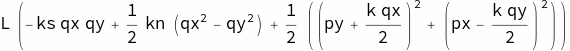
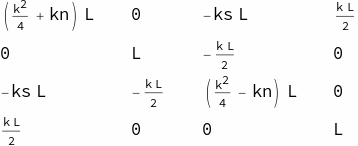

In [84]:
(* quadrupole hamiltonial (normal and skew components) with solenoid *)

H = L (1/2 ((px - k/2 qy)^2 + (py + k/2 qx)^2) + 1/2 kn (qx^2 - qy^2) - ks qx qy)
A = D[H, {{qx, px, qy, py}, 1 + 1}] ;
A // TableForm

2
    k              -2                                       k
---------- + kn + r                                     ----------
4 (1 + dp)              0             -ks               2 (1 + dp)

                          1             1    k
                        ------        -(-) ------
0                       1 + dp          2  1 + dp       0

                                           2
                          1    k          k
                        -(-) ------   ---------- - kn
-ks                       2  1 + dp   4 (1 + dp)        0

    k                                                     1
----------                                              ------
2 (1 + dp)              0             0                 1 + dp
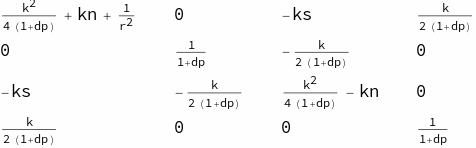

In [88]:
(* generic linear element (homogenious solution) *)

H = (1/2 ((px - k/2 qy)^2 + (py + k/2 qx)^2)/(1 + dp) + 1/2 kn (qx^2 - qy^2) - ks qx qy + 1/2 qx^2/r^2 - dp qx/r) ;
A = D[H, {{qx, px, qy, py}, 1 + 1}] ;
A // TableForm

2     2                  2                     2
L (px  + py  + (1 + dp) (kn qx  - 2 ks qx qy - kn qy ))
-------------------------------------------------------
                      2 (1 + dp)
kn L      0        -(ks L)   0

            L
          ------
0         1 + dp   0         0

-(ks L)   0        -(kn L)   0

                               L
                             ------
0         0        0         1 + dp
              2           2 1/4                                              (
((kn + Sqrt[kn ]) Cos[((kn )    L) / Sqrt[1 + dp]] + 
 
                    2            2 1/4                                 2
>     (-kn + Sqrt[kn ]) Cosh[((kn )    L) / Sqrt[1 + dp]]) / (2 Sqrt[kn ])
 
                     2           2 1/4
>       (kn + Sqrt[kn ]) Sin[((kn )    L) / Sqrt[1 + dp]] + 
 
                     2            2 1/4                                          2 3/4
>      (-kn + Sqrt[kn ]) Sinh[((kn )    L) / Sqrt[1 + dp]]) / (2 Sqrt[1 + dp] (kn )   )
 
>       0   0

  1                    2             2           2 1/4
-(-) (Sqrt[1 + dp] ((kn  + kn Sqrt[kn ]) Sin[((kn )    L) / Sqrt[1 + dp]] + 
  2
 
             2             2            2 1/4                           2 3/4
>        (-kn  + kn Sqrt[kn ]) Sinh[((kn )    L) / Sqrt[1 + dp]])) / (kn )      ((kn + 
                                                                                 
                                                                                >     Sq\
                                                                                 
                                                                                >     rt[
                                                                                 
                                                                                >     kn
                                                                                 
                                                                                     2
                                                                                >     ]) 
                                                                                 
                                                                                >     C\
                                                                                 
                                                                                >    os[
                                                                                 
                                                                                >     
                                                                                 
                                                                                >    (
                                                                                 
                                                                                >    (kn
                                                                                 
                                                                                     2
                                                                                >     )
                                                                                 
                                                                                      1/4
                                                                                >     
                                                                                 
                                                                                >      L)
                                                                                 
                                                                                >      /\
                                                                                 
                                                                                >     Sq\
                                  
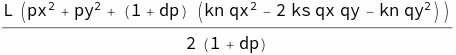
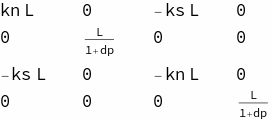
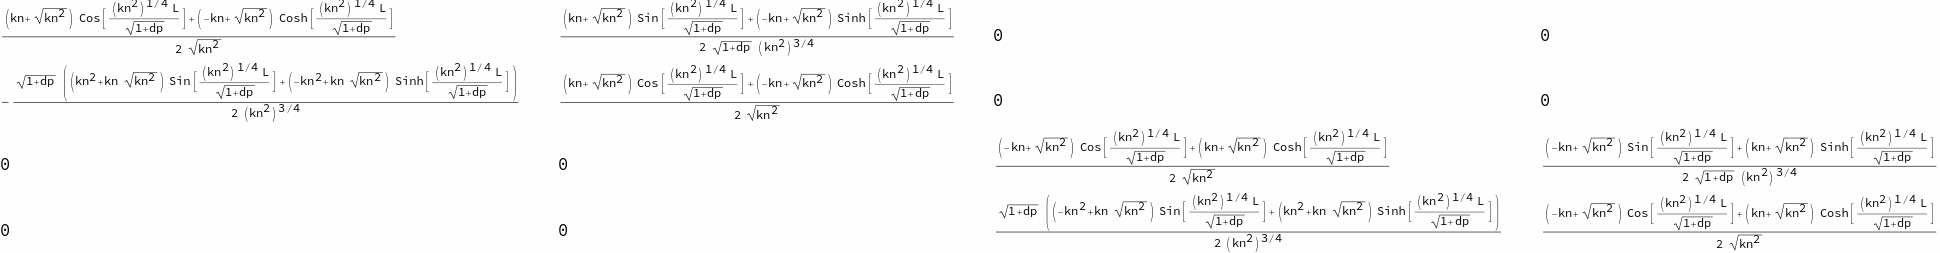
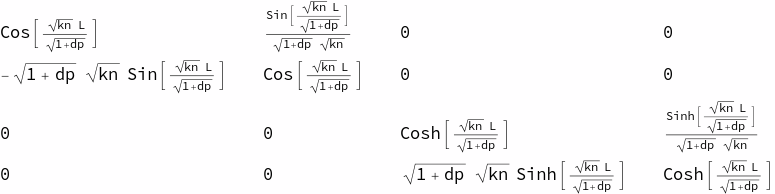
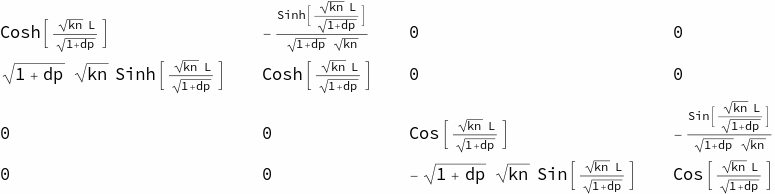

In [92]:
(* homotopy style solution for quadrupole *)

H = L ((1/2 ((px - k/2 qy)^2 + (py + k/2 qx)^2)/(1 + dp) + 1/2 kn (qx^2 - qy^2) - ks qx qy + 1/2 qx^2/r^2 - dp qx/r)) ;
H = Limit[H, {k -> 0, r -> Infinity}] // Simplify 
A = D[H, {{qx, px, qy, py}, 1 + 1}] ;
A // TableForm

M = MatrixExp[S . A] // ExpToTrig // Simplify ;
(M /. ks -> 0) // TableForm

PowerExpand[FullSimplify[M /. ks -> 0, Assumptions -> {kn > 0}]] // TableForm
PowerExpand[FullSimplify[M /. ks -> 0, Assumptions -> {kn < 0}]] // TableForm

Sqrt[k] L               Sqrt[k] L
ka Cos[------------] + kb Cosh[------------]
       Sqrt[1 + dp]            Sqrt[1 + dp]
--------------------------------------------
                    2 k
 
             Sqrt[k] L               Sqrt[k] L
     ka Sin[------------] + kb Sinh[------------]
            Sqrt[1 + dp]            Sqrt[1 + dp]
     --------------------------------------------
                                 3/2
>                2 Sqrt[1 + dp] k
 

               Sqrt[k] L            Sqrt[k] L
     ks (-Cos[------------] + Cosh[------------])
              Sqrt[1 + dp]         Sqrt[1 + dp]
     --------------------------------------------
>                        2 k
 
               Sqrt[k] L            Sqrt[k] L
     ks (-Sin[------------] + Sinh[------------])
              Sqrt[1 + dp]         Sqrt[1 + dp]
     --------------------------------------------
                                 3/2
>                2 Sqrt[1 + dp] k

                        Sqrt[k] L                Sqrt[k] L
Sqrt[1 + dp] (-(ka Sin[------------]) + kb Sinh[------------])
                       Sqrt[1 + dp]             Sqrt[1 + dp]
--------------------------------------------------------------
                          2 Sqrt[k]
 
             Sqrt[k] L               Sqrt[k] L
     ka Cos[------------] + kb Cosh[------------]
            Sqrt[1 + dp]            Sqrt[1 + dp]
     --------------------------------------------
>                        2 k
 
                           Sqrt[k] L            Sqrt[k] L
     Sqrt[1 + dp] ks (Sin[------------] + Sinh[------------])
                          Sqrt[1 + dp]         Sqrt[1 + dp]
     --------------------------------------------------------
>                           2 Sqrt[k]
 
               Sqrt[k] L            Sqrt[k] L
     ks (-Cos[------------] + Cosh[------------])
              Sqrt[1 + dp]         Sqrt[1 + dp]
     --------------------------------------------
>                        2 k


          Sqrt[k] L            Sqrt[k] L
ks (-Cos[------------] + Cosh[------------])
         Sqrt[1 + dp]         Sqrt[1 + dp]
--------------------------------------------
                    2 k
 
               Sqrt[k] L            Sqrt[k] L
     ks (-Sin[------------] + Sinh[------------])
              Sqrt[1 + dp]         Sqrt[1 + dp]
     --------------------------------------------
                                 3/2
>                2 Sqrt[1 + dp] k
 

             Sqrt[k] L               Sqrt[k] L
     kb Cos[------------] + ka Cosh[------------]
            Sqrt[1 + dp]            Sqrt[1 + dp]
     --------------------------------------------
>                        2 k
 
             Sqrt[k] L               Sqrt[k] L
     kb Sin[------------] + ka Sinh[------------]
            Sqrt[1 + dp]            Sqrt[1 + dp]
     --------------------------------------------
                                 3/2
>                2 Sqrt[1 + dp] k

                      Sqrt[k] L            Sqrt[k] L
Sqrt[1 + dp] ks (Sin[------------] + Sinh[------------])
                     Sqrt[1 + dp]         Sqrt[1 + dp]
--------------------------------------------------------
                       2 Sqrt[k]
 
               Sqrt[k] L            Sqrt[k] L
     ks (-Cos[------------] + Cosh[------------])
              Sqrt[1 + dp]         Sqrt[1 + dp]
     --------------------------------------------
>                        2 k
 
                             Sqrt[k] L                Sqrt[k] L
     Sqrt[1 + dp] (-(kb Sin[------------]) + ka Sinh[------------])
                            Sqrt[1 + dp]             Sqrt[1 + dp]
     --------------------------------------------------------------
>                              2 Sqrt[k]
 
             Sqrt[k] L               Sqrt[k] L
     kb Cos[------------] + ka Cosh[------------]
            Sqrt[1 + dp]            Sqrt[1 + dp]
     --------------------------------------------
>                        2 k
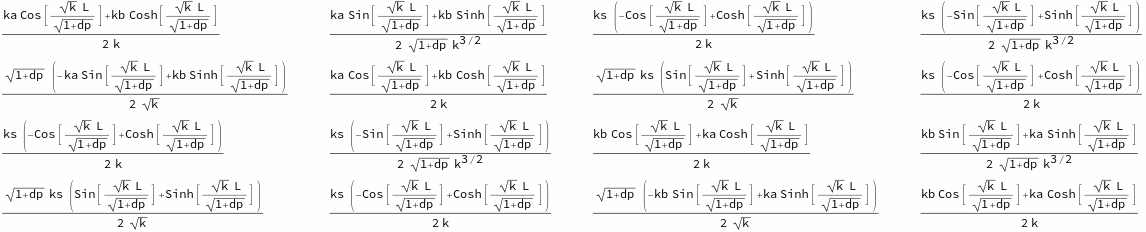

In [101]:
(* simplified form of solution *)

rules = {
    + kn + Sqrt[kn^2 + ks^2] -> ka,
    - kn + Sqrt[kn^2 + ks^2] -> kb,
    + kn^2 + ks^2 -> + k^2,
    - kn^2 - ks^2 -> - k^2,
    + kn + k -> ka,
    - kn + k -> kb,
    - kn - k -> - ka,
    + kn - k -> - kb
} ;

solution = M //. rules // Simplify // PowerExpand // Expand ;
solution = Collect[solution //. rules // Simplify // PowerExpand, {Sin[_], Cos[_], Sinh[_], Cosh[_]}, Simplify] ;
solution = Collect[solution //. rules // Simplify // PowerExpand, {Sin[_], Cos[_], Sinh[_], Cosh[_]}, Simplify] ;
solution // Simplify // TableForm

b   0   0   0

0   a   0   0

0   0   d   0

0   0   0   c
                                  Sqrt[a] Sin[Sqrt[a] Sqrt[b]]
                                  ----------------------------
Cos[Sqrt[a] Sqrt[b]]                        Sqrt[b]
 


>    0                                 0

  Sqrt[b] Sin[Sqrt[a] Sqrt[b]]
-(----------------------------)
            Sqrt[a]               Cos[Sqrt[a] Sqrt[b]]
 


>    0                                 0



0                                 0
 
                                       Sqrt[c] Sin[Sqrt[c] Sqrt[d]]
                                       ----------------------------
>    Cos[Sqrt[c] Sqrt[d]]                        Sqrt[d]



0                                 0
 
       Sqrt[d] Sin[Sqrt[c] Sqrt[d]]
     -(----------------------------)
>                Sqrt[c]               Cos[Sqrt[c] Sqrt[d]]
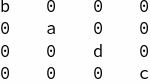
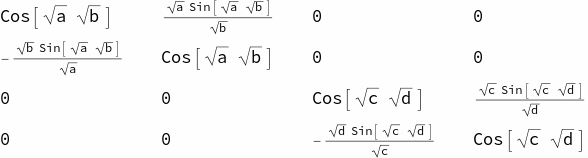

In [107]:
(* id transpornt matrix exponent (wiggler) *)

H = 1/2 (a px^2 + b qx^2) + 1/2 (c py^2 + d qy^2) ;
A = D[H, {{qx, px, qy, py}, 1 + 1}] ;
A // TableForm

M = MatrixExp[S . A] // ExpToTrig // Simplify ;
M // TableForm

b   0   0   e

0   a   f   0

0   f   d   0

e   0   0   c
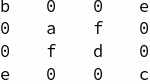

In [113]:
(* id transpornt matrix exponent (apple-ii) *)

H = 1/2 (a px^2 + b qx^2) + 1/2 (c py^2 + d qy^2) + e qx py + f px qy ;
A = D[H, {{qx, px, qy, py}, 1 + 1}] ;
A // TableForm

b   0   e   0

0   a   0   f

e   0   d   0

0   f   0   c
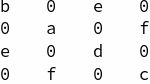

In [117]:
(* id transpornt matrix exponent (figure-eight) *)

H = 1/2 (a px^2 + b qx^2) + 1/2 (c py^2 + d qy^2) + e qx qy + f px py ;
A = D[H, {{qx, px, qy, py}, 1 + 1}] ;
A // TableForm

In [121]:
(* thin insertion exponential form for drift-kick-drift *)
(* note, the cross term is zero due to time reversibility of individual parts *)
(* since this holds for individual parts, it hold for the composition *)
(* corresponding exponents is diagonal (or doesn't contain the crossed term) *)

S = {{0, 1}, {-1, 0}} ;

H0 = a/2 p^2 + b/2 q^2 ;
H1 = c/2 p^2 + d/2 q^2 ;

A0 = D[H0, {{q, p}, 1 + 1}]  ;
A1 = D[H1, {{q, p}, 1 + 1}]  ;

M0 = MatrixExp[- 1/2 S . A0] // Simplify // ExpToTrig // Simplify ;
M1 = MatrixExp[+ 1/1 S . A1] // Simplify // ExpToTrig // Simplify ;
M2 = M0 . M1 . M0 // Simplify // ExpToTrig // Simplify ;

A2 = - S . MatrixLog[M2] // Simplify // ExpToTrig // Simplify ;
A2 = 1/2 (A2 + Transpose[A2])  // Simplify // ExpToTrig // Simplify ;
A2 - DiagonalMatrix[Diagonal[A2]] // Simplify

{{0, 0}, {0, 0}}

# Transport matrix (Elleaume potential)

In [1]:
(* Focusing parameters k_x and k_y are computed from the Elleaume potential *)
(* They can be used to compute the full n-period transport matrix as the n-th power of a one-period matrix *)
(* The one-period matrix itself can be approximated by a simple drift-kick-drift sequence of matrices *)
(* One needs to transform slope-based kicks into canonical-momentum kicks to obtain the correct energy dependence *)
(* However, the slope-based kicks are approximate in energy *)
(* The exponential representation of the n-period matrix, expressed as a thin insertion, is diagonal and exact, but the resulting expression is complicated and not practical *)
(* Approximate relations between the ID parameters (k_x, k_y, period length, and number of periods) and the diagonal elements of the transport-matrix exponent are presented to second order in the focusing parameters *)
(* Additionally, for nonzero momentum deviation, it is possible to derive a transport matrix that accounts for chromatic effects *)
(* The paraxial approximation is used for the drift transformation *)
(* Without coupling, the derivation can be performed for one transverse plane at a time *)

0    1

-1   0
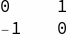

In [11]:
(* skew symplectic identity matrix (single plane) *)

S = {{0, 1}, {-1, 0}} ;
S // TableForm

lp
    ----------
1   2 (1 + dp)

0   1
1           0

    kx
-(------)
  1 + dp    1
                                2
       kx lp      lp (4 (1 + dp)  - kx lp)
1 - -----------   ------------------------
              2                   3
    2 (1 + dp)          4 (1 + dp)

                         kx lp
    kx            1 - -----------
-(------)                       2
  1 + dp              2 (1 + dp)
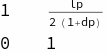
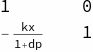
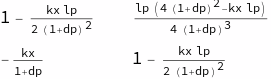

In [14]:
(* drift-kick-drift one-period matrix *)
(* note, while px = (1 + dp) x' in paraxial approximation, the kick itself is proportional 1/energy^2, i.e. to 1/(1 + dp)^2 *)
(* and the kick dependence on energy is approximate *)

(* drift (half period length) *)

ClearAll[MD] ;
MD = {{1, lp/2/(1 + dp)}, {0, 1}} ;
MD // TableForm

(* kick (canonical momenta) *)

ClearAll[MK] ;
MK = {{1, 0}, {-kx/(1 + dp), 1}} ;
MK // TableForm

(* drift-kick-drift (one period) *)

ClearAll[MDMKMD] ;
MDMKMD = MD . MK . MD // FullSimplify  ;
MDMKMD // TableForm

In [29]:
(* thin n-period insertion matrix *)
(* (MD)^(-np) MDMKMD^np (MD)^(-np) -> identity iff kx === 0 *)
(* note, this matrix is exact, but the expression is compicated *)

DR = {{1, - (np lp)/2/(1 + dp)}, {0, 1}} ;
MT = DR . MatrixPower[MDMKMD, np] . DR // Simplify ;
Limit[MT, {kx -> 0}]

{{1, 0}, {0, 1}}

2   2   2         2               2            2      2   3            4
    kx  lp  np  (-1 + np )         kx lp  np (-1 + np )   kx  lp  np (-1 + np )
1 - ----------------------         -------------------- + ---------------------
                    4                             3                       5
         24 (1 + dp)                   12 (1 + dp)            120 (1 + dp)

              2               2          2   2   2         2
  kx np     kx  lp np (-1 + np )       kx  lp  np  (-1 + np )
-(------) + --------------------   1 - ----------------------
  1 + dp                  3                            4
                6 (1 + dp)                  24 (1 + dp)
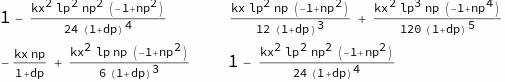

In [35]:
(* transpornt matrix series expansion (not symplectic) *)

order = 1 + 1 ;

MS = Collect[(Series[MT /. {kx -> t kx}, {t, 0, order}, Assumptions -> {Element[_, Reals]}] // Normal // Simplify) /. t -> 1, {kx}, FullSimplify] ; 
MS // TableForm

In [39]:
(* symmetric exponent matrix construction *)
(* note, since the initial transport matrix is symplectic *)
(* computed exponential representation is symmetric and it's futher symmetrization doesn't change the expression *)
(* symmetrizatoin here is performed to simplify the final symbolic result *)
(* it is also possible to compute the exponent starting from the truncated matrix and this will produce identical truncated result *)

A = Simplify[- S . MatrixLog[MT]] ;
A = Simplify[1/2 (A + Transpose[A])] ;
DiagonalMatrixQ[A]

True

0.0389562   0           0            0

0           0.0541579   0            0

0           0           -0.0624781   0

0           0           0            -0.0780438
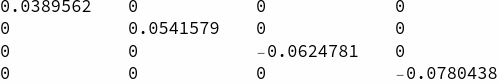

In [47]:
(* test matrix exponent with realistic numerical data *)
(* note, all elements but the diagonal ones are exact zeros *)
(* this is a feature of thin insertion type representation *)

AX = A /. kx -> kx ;
AY = A /. kx -> ky ;

ArrayFlatten[{{AX, 0}, {0, AY}}] /. {lp -> 0.1, np  -> 40, kx -> +0.001, ky -> -0.0015, dp -> 0.0} // Re // TableForm

kx np
------
1 + dp
     2            2
kx lp  np (-1 + np )
--------------------
               3
    12 (1 + dp)
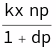
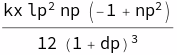

In [53]:
(* 1st order series exponent expansion with respect to focusing parameters *)

order = 1 ;

{a, b} = Diagonal[A] /. {kx -> t kx} ;

a$s = (Series[a, {t, 0, order}, Assumptions -> {Element[kx, Reals], lp > 0, t > 0, Element[np, Integers], np > 0}] // Normal) /. t -> 1 // Simplify // ComplexExpand // Collect[#, {kx}, FullSimplify] & 
b$s = (Series[b, {t, 0, order}, Assumptions -> {Element[kx, Reals], lp > 0, t > 0, Element[np, Integers], np > 0}] // Normal) /. t -> 1 // Simplify // ComplexExpand // Collect[#, {kx}, FullSimplify] & 

2            2
            kx lp  np (-1 + np )
            --------------------
                           3
1               12 (1 + dp)

  kx np
-(------)
  1 + dp    1
                 2            2
            kx lp  np (-1 + np )
            --------------------
                           3
1               12 (1 + dp)

  kx np
-(------)
  1 + dp    1
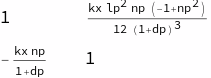
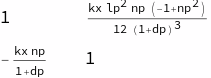

In [58]:
(* 1st order transport matrix *)

order = 1 ;

Collect[(Series[MatrixExp[S . DiagonalMatrix[{a$s, b$s}]] /. {kx -> t kx}, {t, 0, order}, Assumptions -> Element[_, Reals]] // Normal // Simplify) /. t -> 1, {kx}, FullSimplify] // TableForm
Collect[(Series[MT /. {kx -> t kx}, {t, 0, order}, Assumptions -> Element[_, Reals]] // Normal // Simplify) /. t -> 1, {kx}, FullSimplify] // TableForm

2               2
kx np    kx  lp np (-1 + np )
------ - --------------------
1 + dp                 3
             6 (1 + dp)
     2            2      2   3            4
kx lp  np (-1 + np )   kx  lp  np (-1 + np )
-------------------- + ---------------------
               3                       5
    12 (1 + dp)            120 (1 + dp)
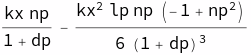
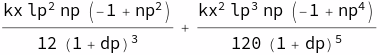

In [62]:
(* 2nd order series expansion with respect to focusing parameters *)

order = 1 + 1 ;

{a, b} = Diagonal[A] /. {kx -> t kx} ;

a$s = (Series[a, {t, 0, order}, Assumptions -> {Element[kx, Reals], lp > 0, t > 0, Element[n, Integers], np > 0}] // Normal) /. t -> 1 // Simplify // ComplexExpand // Collect[#, {kx}, FullSimplify] & 
b$s = (Series[b, {t, 0, order}, Assumptions -> {Element[kx, Reals], lp > 0, t > 0, Element[n, Integers], np > 0}] // Normal) /. t -> 1 // Simplify // ComplexExpand // Collect[#, {kx}, FullSimplify] & 

2   2   2         2               2            2      2   3            4
    kx  lp  np  (-1 + np )         kx lp  np (-1 + np )   kx  lp  np (-1 + np )
1 - ----------------------         -------------------- + ---------------------
                    4                             3                       5
         24 (1 + dp)                   12 (1 + dp)            120 (1 + dp)

              2               2          2   2   2         2
  kx np     kx  lp np (-1 + np )       kx  lp  np  (-1 + np )
-(------) + --------------------   1 - ----------------------
  1 + dp                  3                            4
                6 (1 + dp)                  24 (1 + dp)
      2   2   2         2               2            2      2   3            4
    kx  lp  np  (-1 + np )         kx lp  np (-1 + np )   kx  lp  np (-1 + np )
1 - ----------------------         -------------------- + ---------------------
                    4                             3                       5
         24 (1 + dp)                   12 (1 + dp)            120 (1 + dp)

              2               2          2   2   2         2
  kx np     kx  lp np (-1 + np )       kx  lp  np  (-1 + np )
-(------) + --------------------   1 - ----------------------
  1 + dp                  3                            4
                6 (1 + dp)                  24 (1 + dp)
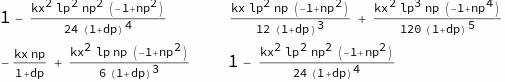
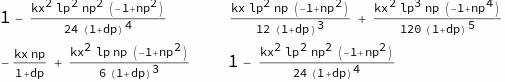

In [67]:
(* 2n order exponents and transport matrix *)

order = 1 + 1 ;

Collect[(Series[MatrixExp[S . DiagonalMatrix[{a$s, b$s}]] /. {kx -> t kx}, {t, 0, order}, Assumptions -> Element[_, Reals]] // Normal // FullSimplify) /. t -> 1, {kx}, Simplify] // TableForm
Collect[(Series[MT /. {kx -> t kx}, {t, 0, order}, Assumptions -> Element[_, Reals]] // Normal // Simplify) /. t -> 1, {kx}, FullSimplify] // TableForm

In [71]:
(* exponent construction from the truncated transport matrix *)

AS = -S . MatrixLog[MS] ;
AS = 1/2 (AS + Transpose[AS]) ;
AS = Normal[Series[AS /. {kx -> t kx}, {t, 0, order}]]  /. t -> 1 ;
{a$s, b$s} - Diagonal[AS] // Simplify

{0, 0}

2               2
kx np    kx  lp np (-1 + np )
------ - --------------------
1 + dp                 3
             6 (1 + dp)

     2            2      2   3            4
kx lp  np (-1 + np )   kx  lp  np (-1 + np )
-------------------- + ---------------------
               3                       5
    12 (1 + dp)            120 (1 + dp)

           2               2
ky np    ky  lp np (-1 + np )
------ - --------------------
1 + dp                 3
             6 (1 + dp)

     2            2      2   3            4
ky lp  np (-1 + np )   ky  lp  np (-1 + np )
-------------------- + ---------------------
               3                       5
    12 (1 + dp)            120 (1 + dp)
kx

0

ky

0
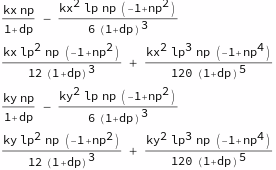

In [76]:
(* approximate expressions for diagonal elements *)

diagonal = {
    (kx*np)/(1 + dp) - (kx^2*lp*np*(-1 + np^2))/(6*(1 + dp)^3),
    (kx*lp^2*np*(-1 + np^2))/(12*(1 + dp)^3) + (kx^2*lp^3*np*(-1 + np^4))/(120*(1 + dp)^5),
    (ky*np)/(1 + dp) - (ky^2*lp*np*(-1 + np^2))/(6*(1 + dp)^3),
    (ky*lp^2*np*(-1 + np^2))/(12*(1 + dp)^3) + (ky^2*lp^3*np*(-1 + np^4))/(120*(1 + dp)^5)
} ;

diagonal // TableForm
diagonal /. np -> 1 /. dp -> 0 // TableForm

In [80]:
(* compare Radia RK tracking and potentials *)

Normal[Series[diagonal /. {kx -> t kx, ky -> t ky}, {t, 0, 1}]] /. t -> 1 /. {lp -> 0.10036, np -> 40, kx -> - 0.0008418142893213273, ky -> + 0.0014623657005811024, dp -> 0}
Normal[Series[diagonal /. {kx -> t kx, ky -> t ky}, {t, 0, 1 + 1}]] /. t -> 1 /. {lp -> 0.10036, np -> 40, kx -> - 0.0008418142893213273, ky -> + 0.0014623657005811024, dp -> 0}
{-0.034441907232402175, -0.04458009513208418, 0.056279356423643276, 0.08037110220505986}

{-0.0336726, -0.0451923, 0.0584946, 0.0785063}
{-0.0344307, -0.0445811, 0.0562068, 0.0803509}
{-0.0344419, -0.0445801, 0.0562794, 0.0803711}

In [84]:
(* idtm *)

ClearAll[idtm] ;
idtm::usage = "idtm[{kx, ky}, np, lp, dp] -- compute id thin insertion exponent diagonal and corresponding transport matrix (second order in kx and kz)" ;
idtm[                         (* -- id thin insertion diagonal and transport matrix *)
	{kx_, ky_},               (* -- focusing strength (1/m) *)
	count_,                   (* -- total number of (super) periods *)
	period_,                  (* -- (super) period length (m) *)
	delta_                    (* -- energy delta *)
] := Block[
	{a, b, c, d, diagonal, matrix},
	a = (kx*count)/(1 + delta) - (kx^2*period*count*(-1 + count^2))/(6*(1 + delta)^3) ;
	b = (kx*period^2*count*(-1 + count^2))/(12*(1 + delta)^3) + (kx^2*period^3*count*(-1 + count^4))/(120*(1 + delta)^5) ;
	c = (ky*count)/(1 + delta) - (ky^2*period*count*(-1 + count^2))/(6*(1 + delta)^3); 
	d = (ky*period^2*count*(-1 + count^2))/(12*(1 + delta)^3) + (ky^2*period^3*count*(-1 + count^4))/(120*(1 + delta)^5) ;
	diagonal = {a, b, c, d} ;
	matrix = MatrixExp[{{0, 1, 0, 0}, {-1, 0, 0, 0}, {0, 0, 0, 1}, {0, 0, -1, 0}} . DiagonalMatrix[diagonal]] ;
	{diagonal, matrix}   
] ;

In [88]:
(* compute approximate exponent and corresponding symplectic transport matrix *)

{exponent, matrix} = idtm[{-0.000841814289321327, + 0.0014623657005811024}, 40, 0.10036, 0.0] ;
exponent

{-0.0344307, -0.0445811, 0.0562068, 0.0803509}

0.999232    -0.0445722   0.           0.

0.0344358   0.999232     0.           0.

0.          0.           0.99774      0.080305

0.          0.           -0.0562334   0.99774
0.999233    -0.0445697   0.           0.

0.0344219   0.999233     0.           0.

0.          0.           0.997743     0.0802905

0.          0.           -0.0561645   0.997743
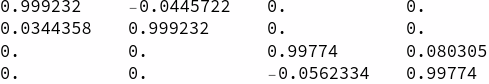
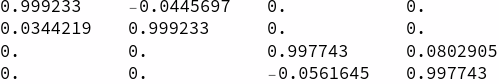

In [91]:
(* compare transport matrix elements *)

ArrayFlatten[{{MT, 0}, {0, MT /. kx -> ky}}] /. {lp -> 0.10036, np -> 40, kx -> - 0.0008418142893213273, ky -> + 0.0014623657005811024, dp -> 0} // Re // N // TableForm
matrix // TableForm

In [94]:
(* diagonal exponent rules *)

rules = {
    ca -> (kx*np)/(1 + dp) - (kx^2*lp*np*(-1 + np^2))/(6*(1 + dp)^3),
    cb -> (kx*lp^2*np*(-1 + np^2))/(12*(1 + dp)^3) + (kx^2*lp^3*np*(-1 + np^4))/(120*(1 + dp)^5),
    cc -> (ky*np)/(1 + dp) - (ky^2*lp*np*(-1 + np^2))/(6*(1 + dp)^3),
    cd -> (ky*lp^2*np*(-1 + np^2))/(12*(1 + dp)^3) + (ky^2*lp^3*np*(-1 + np^4))/(120*(1 + dp)^5)
} ;

2        2
       60 cb + 3 ca lp  (1 + np )
{kx -> --------------------------}
             2              2
         2 lp  np (-1 + 4 np )
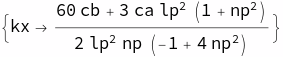

In [96]:
(* focusing paramter in terms of diagonal elements *)

focusing = FullSimplify[First[Solve[(1/20 lp^2 (1 + np^2) ca + cb /. rules /. dp -> 0) == (1/20 lp^2 (1 + np^2) ca + cb), kx]]]

2        2
       60 cb + 3 ca lp  (1 + np )
{kx -> --------------------------}
             2              2
         2 lp  np (-1 + 4 np )
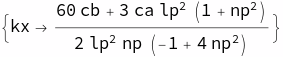

In [98]:
focusing = {kx -> (60*cb + 3*ca*lp^2*(1 + np^2))/(2*lp^2*np*(-1 + 4*np^2))}

# Transport matrix (deviation)

In [1]:
(* For a fixed set of tunable ID parameters, one can compute the corresponding linear focusing parameters and the resulting transport matrix *)
(* Changing the ID parameters leads to a different set of the focusing parameters *)
(* Here we compute the transport matrix corresponding to a small change in the ID parameters that depends on initial ID parameters and the change implicitly *)

In [4]:
(* idtm *)
(* note, the inverse matrix can be obtained by substituting kx -> - kx, kz -> -kz and lp -> -lp *)

ClearAll[idtm] ;
idtm::usage = "idtm[{kx, ky}, np, lp, dp] -- compute id thin insertion exponent diagonal and corresponding transport matrix (second order in kx and kz)" ;
idtm[                         (* -- id thin insertion diagonal and transport matrix *)
	{kx_, ky_},               (* -- focusing strength (1/m) *)
	count_,                   (* -- total number of (super) periods *)
	period_,                  (* -- (super) period length (m) *)
	delta_                    (* -- energy delta *)
] := Block[
	{a, b, c, d, diagonal, matrix},
	a = (kx*count)/(1 + delta) - (kx^2*period*count*(-1 + count^2))/(6*(1 + delta)^3) ;
	b = (kx*period^2*count*(-1 + count^2))/(12*(1 + delta)^3) + (kx^2*period^3*count*(-1 + count^4))/(120*(1 + delta)^5) ;
	c = (ky*count)/(1 + delta) - (ky^2*period*count*(-1 + count^2))/(6*(1 + delta)^3); 
	d = (ky*period^2*count*(-1 + count^2))/(12*(1 + delta)^3) + (ky^2*period^3*count*(-1 + count^4))/(120*(1 + delta)^5) ;
	diagonal = {a, b, c, d} ;
	matrix = MatrixExp[{{0, 1, 0, 0}, {-1, 0, 0, 0}, {0, 0, 0, 1}, {0, 0, -1, 0}} . DiagonalMatrix[diagonal]] ;
	{diagonal, matrix}   
] ;

In [9]:
(* test inverse transport matrix *)

Last[idtm[- {kx, kz}, np, -lp, dp]] . Last[idtm[{kx, kz}, np, lp, dp]] // Simplify

{{1, 0, 0, 0}, {0, 1, 0, 0}, {0, 0, 1, 0}, {0, 0, 0, 1}}

0    1   0    0

-1   0   0    0

0    0   0    1

0    0   -1   0
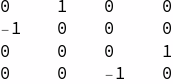

In [11]:
(* skew symplectici dentity matrix *)

S = {{0, 1, 0, 0}, {-1, 0, 0, 0}, {0, 0, 0, 1}, {0, 0, -1, 0}} ;
S // TableForm

2   2   2         2
    dkx  lp  np  (-1 + np )
1 - -----------------------
                    4
         24 (1 + dp)
 
        2   3            4          2            2                   2                2
     dkx  lp  np (-1 + np )   dkx lp  np (-1 + np ) (5 + 10 dp + 5 dp  + kx lp (1 + np ))
     ---------------------- + -----------------------------------------------------------
                     5                                          5
>        120 (1 + dp)                                60 (1 + dp)
 




>       0
 




>    0

   2               2                       2                   2
dkx  lp np (-1 + np )   dkx np (-6 (1 + dp)  + 2 kx lp (-1 + np ))
--------------------- + ------------------------------------------
               3                                 3
     6 (1 + dp)                        6 (1 + dp)
 
            2   2   2         2
         dkx  lp  np  (-1 + np )
     1 - -----------------------
                         4
>             24 (1 + dp)
 




>       0
 




>    0





0
 




>    0
 
               2   2   2         2
            dkz  lp  np  (-1 + np )
        1 - -----------------------
                            4
>                24 (1 + dp)
 
        2   3            4          2            2                   2                2
     dkz  lp  np (-1 + np )   dkz lp  np (-1 + np ) (5 + 10 dp + 5 dp  + kz lp (1 + np ))
     ---------------------- + -----------------------------------------------------------
                     5                                          5
>        120 (1 + dp)                                60 (1 + dp)





0
 




>    0
 
           2               2                       2                   2
        dkz  lp np (-1 + np )   dkz np (-6 (1 + dp)  + 2 kz lp (-1 + np ))
        --------------------- + ------------------------------------------
                       3                                 3
>            6 (1 + dp)                        6 (1 + dp)
 
            2   2   2         2
         dkz  lp  np  (-1 + np )
     1 - -----------------------
                         4
>             24 (1 + dp)
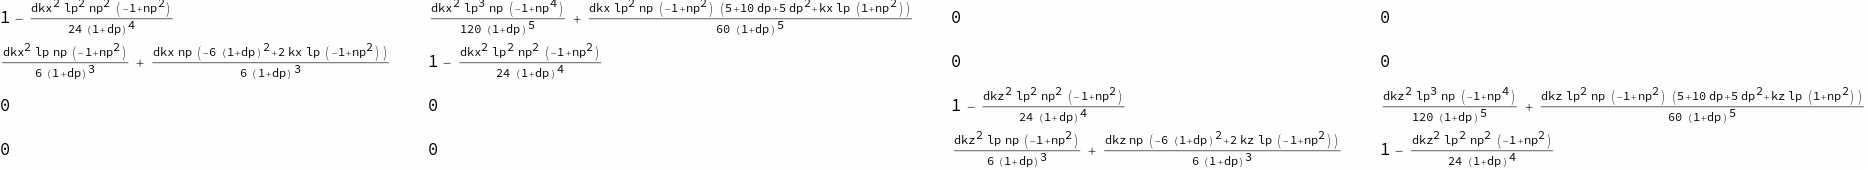

In [14]:
(* compute truncated perturbation matrix *)

matrix = Last[idtm[- t {kx, kz}, np, -lp, dp]] . Last[idtm[t {kx + dkx, kz + dkz}, np, lp, dp]] ;
matrix = Collect[Simplify[Normal[Series[matrix, {t, 0, 1 + 1}]]], {dkx, dkz}, Simplify] ;
matrix /. t -> 1 // TableForm

2               2                                   2
  1  dkx  lp np (-1 + np )          np     kx lp np (-1 + np )
-(-) --------------------- + dkx (------ - -------------------)
  6                3              1 + dp                 3
           (1 + dp)                            3 (1 + dp)
 




>    0
 




>       0
 




>    0





0
 
        2   3            4          2            2                   2                2
     dkx  lp  np (-1 + np )   dkx lp  np (-1 + np ) (5 + 10 dp + 5 dp  + kx lp (1 + np ))
     ---------------------- + -----------------------------------------------------------
                     5                                          5
>        120 (1 + dp)                                60 (1 + dp)
 




>       0
 




>    0





0
 




>    0
 
                2               2                                   2
          1  dkz  lp np (-1 + np )          np     kz lp np (-1 + np )
        -(-) --------------------- + dkz (------ - -------------------)
          6                3              1 + dp                 3
>                  (1 + dp)                            3 (1 + dp)
 




>    0





0
 




>    0
 




>       0
 
        2   3            4          2            2                   2                2
     dkz  lp  np (-1 + np )   dkz lp  np (-1 + np ) (5 + 10 dp + 5 dp  + kz lp (1 + np ))
     ---------------------- + -----------------------------------------------------------
                     5                                          5
>        120 (1 + dp)                                60 (1 + dp)
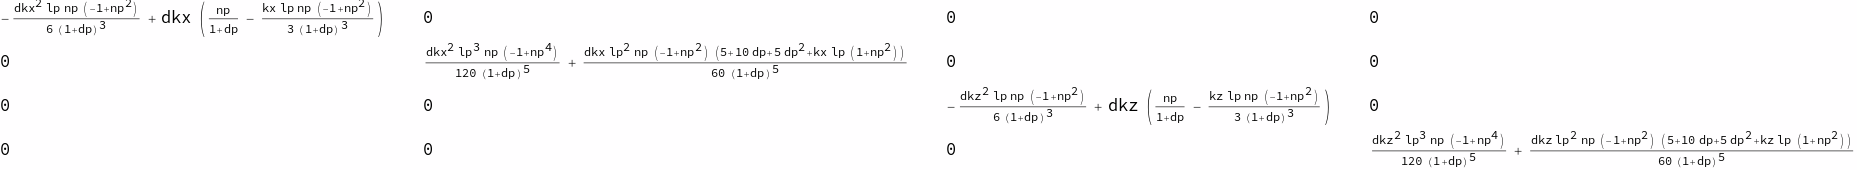

In [18]:
(* compute corresponding exponent *)

exponent = Collect[Simplify[Normal[Series[-S . MatrixLog[matrix], {t, 0, 1 + 1}]] /. t -> 1], {dkx, dkz}, Simplify] ;
exponent // TableForm

0.999236   -0.0444375   0.           0.

0.034386   0.999236     0.           0.

0.         0.           0.997752     0.0800467

0.         0.           -0.0561131   0.997752
0.999875   -0.0181941   0.           0.

0.013783   0.999875     0.           0.

0.         0.           0.99902      0.0522872

0.         0.           -0.0374561   0.99902
0.999881    -0.018194   0.           0.

0.0137831   0.999868    0.           0.

0.          0.          0.998988     0.0522884

0.          0.          -0.0374553   0.999052
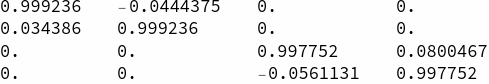
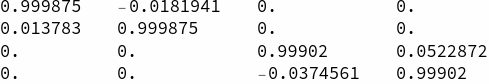
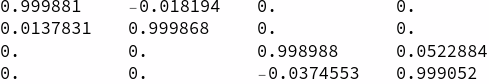

In [21]:
(* test perturbation matrix on numerical data *)

rule = {
    kx -> - 0.0008418142893213270,
    kz -> + 0.0014623657005811024,
    np -> 40,
    lp -> 0.10036,
    dkx -> + 0.0005,
    dkz -> - 0.0005,
    dp -> 0.001
} ;

Last[idtm[{kx, kz}, np, lp, dp]] /. rule // Chop // N // TableForm
Last[idtm[{kx + dkx, kz + dkz}, np, lp, dp]] /. rule // Chop // N // TableForm
Last[idtm[{kx, kz}, np, lp, dp]] . MatrixExp[S . exponent] /. rule // Chop // N // TableForm

In [26]:
rule = {
    kx -> - 0.0008418142893213270,
    kz -> + 0.0014623657005811024,
    np -> 40,
    lp -> 0.10036,
    dkx -> + 0.0005,
    dkz -> - 0.0005,
    dp -> 0.0
} ;

In [27]:
(* diagonal exponent rules *)

rules = {
    ca -> (kx*np)/(1 + dp) - (kx^2*lp*np*(-1 + np^2))/(6*(1 + dp)^3),
    cb -> (kx*lp^2*np*(-1 + np^2))/(12*(1 + dp)^3) + (kx^2*lp^3*np*(-1 + np^4))/(120*(1 + dp)^5),
    cc -> (ky*np)/(1 + dp) - (ky^2*lp*np*(-1 + np^2))/(6*(1 + dp)^3),
    cd -> (ky*lp^2*np*(-1 + np^2))/(12*(1 + dp)^3) + (ky^2*lp^3*np*(-1 + np^4))/(120*(1 + dp)^5)
} ;

In [29]:
(* focusing *)

focusing = {kx -> (60*cb + 3*ca*lp^2*(1 + np^2))/(2*lp^2*np*(-1 + 4*np^2))} ;

(kx /. rule)
(kx /. focusing /. Thread[{ca, cb, cc, cd} -> First[idtm[{kx, kz}, np, lp, dp]] /. rule] /. rule)

-0.000841814
-0.000841814

# Optics distortion (generic uncoupled)

In [1]:
(* Effects of generic uncoupled perturbation are derived using exponential representation of the perturbation *)
(* Special cases are considered along with transparency condition and resulting tune shifts *)

0    1   0    0

-1   0   0    0

0    0   0    1

0    0   -1   0
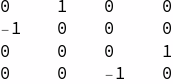

In [3]:
(* skew symplectic identity matrix *)

S = {{0, 1, 0, 0}, {-1, 0, 0, 0}, {0, 0, 0, 1}, {0, 0, -1, 0}} ;
S // TableForm

2        2                   2                   2
Cx px    Cy py               Ax qx               Ay qy
------ + ------ + Bx px qx + ------ + By py qy + ------
  2        2                   2                   2
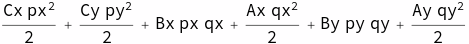

In [6]:
(* generic uncoupled perturbation Hamiltonian *)

hamiltonian = (Ax qx^2/2 + Bx qx px + Cx px^2/2) + (Ay qy^2/2 + By qy py + Cy py^2/2)

Ax   Bx   0    0

Bx   Cx   0    0

0    0    Ay   By

0    0    By   Cy
                                 2                    2
            2     Bx Sinh[Sqrt[Dx ]]   Cx Sinh[Sqrt[Dx ]]
Cosh[Sqrt[Dx ]] + ------------------   ------------------
                             2                    2
                      Sqrt[Dx ]            Sqrt[Dx ]
 




>    0                                      0

                 2                                                      2
  Ax Sinh[Sqrt[Dx ]]                               2     Bx Sinh[Sqrt[Dx ]]
-(------------------)                  Cosh[Sqrt[Dx ]] - ------------------
             2                                                      2
      Sqrt[Dx ]                                              Sqrt[Dx ]
 




>    0                                      0





0                                      0
 
                                      2                    2
                 2     By Sinh[Sqrt[Dy ]]   Cy Sinh[Sqrt[Dy ]]
     Cosh[Sqrt[Dy ]] + ------------------   ------------------
                                  2                    2
>                          Sqrt[Dy ]            Sqrt[Dy ]





0                                      0
 
                      2                                                      2
       Ay Sinh[Sqrt[Dy ]]                               2     By Sinh[Sqrt[Dy ]]
     -(------------------)                  Cosh[Sqrt[Dy ]] - ------------------
                  2                                                      2
>          Sqrt[Dy ]                                              Sqrt[Dy ]
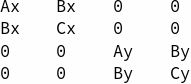
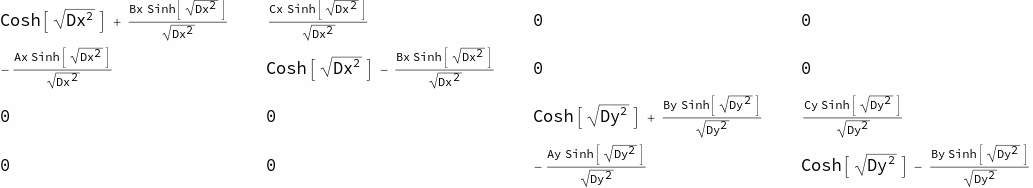

In [8]:
(* solution for the above can be represented as exp(S A) with A being the Hessian of the hamiltonian *)

A = D[hamiltonian, {{qx, px, qy, py}, 1 + 1}] ;
M = MatrixExp[S . A] // ExpToTrig // Simplify ;

A // TableForm
M /. {Bx^2 - Ax Cx -> Dx^2, By^2 - Ay Cy -> Dy^2} // TableForm

Cos[2 nux Pi] + ax Sin[2 nux Pi]   bx Sin[2 nux Pi]
 
>    0                                  0

        2
(-1 - ax ) Sin[2 nux Pi]
------------------------
           bx                      Cos[2 nux Pi] - ax Sin[2 nux Pi]
 



>    0                                  0

0                                  0                                  Cos[2 nuy Pi] + 
 
>    ay Sin[2 nuy Pi]   by Sin[2 nuy Pi]




0                                  0
 
             2
     (-1 - ay ) Sin[2 nuy Pi]
     ------------------------
>               by                      Cos[2 nuy Pi] - ay Sin[2 nuy Pi]
1
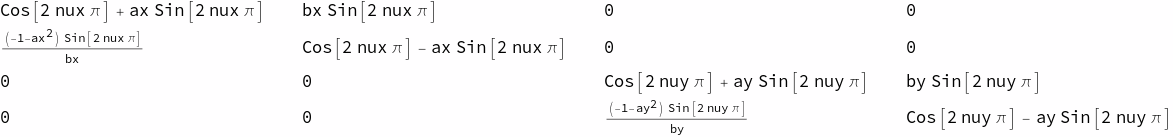

In [13]:
(* CS one-turn uncoupled transport matrix *)

Clear[CS] ;
CS[{ax_, bx_, nux_}, {ay_, by_, nuy_}] := {
	{Cos[2 Pi nux] + ax Sin[2 Pi nux], bx Sin[2 Pi nux], 0, 0},
	{-(1 + ax^2)/bx Sin[2 Pi nux], Cos[2 Pi nux] - ax Sin[2 Pi nux], 0, 0},
	{0, 0, Cos[2 Pi nuy] + ay Sin[2 Pi nuy], by Sin[2 Pi nuy]},
	{0, 0, -(1 + ay^2)/by Sin[2 Pi nuy], Cos[2 Pi nuy] - ay Sin[2 Pi nuy]}
} ;

CS[{ax, bx, nux}, {ay, by, nuy}] // TableForm
CS[{ax, bx, nux}, {ay, by, nuy}] // Det // Simplify

2
2 (1 + ax ) nux Pi
------------------
        bx           2 ax nux Pi   0                    0

2 ax nux Pi          2 bx nux Pi   0                    0

                                            2
                                   2 (1 + ay ) nuy Pi
                                   ------------------
0                    0                     by           2 ay nuy Pi

0                    0             2 ay nuy Pi          2 by nuy Pi
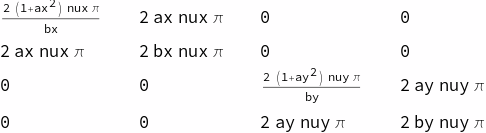

In [18]:
(* exponential form of CS one-turn matrix *)

A$CS = FullSimplify[- S . MatrixLog[CS[{ax, bx, nux}, {ay, by, nuy}]], Assumptions -> Element[_, Reals]] ;
A$CS // TableForm

2    2
               2                (1 + ax ) qx
2 nux Pi (bx px  + 2 ax px qx + -------------) + 
                                     bx
 
                                           2    2
                   2                (1 + ay ) qy
>   2 nuy Pi (by py  + 2 ay py qy + -------------)
                                         by
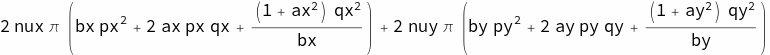

In [21]:
(* corresponding Hamiltonian (sum of invariant actions) *)

I$CS = Collect[{qx, px, qy, py} . A$CS . {qx, px, qy, py}, {2 Pi nux, 2 Pi nuy}]

In [23]:
(* transport matrix between locations two locations (normalized form) *)

(* M(s1 -> s2) = N(s2) R(s1 -> s2) N(s1)^-1 *)

(* transformation between floquet amd normalized coordinates *)

Clear[normal];
normal[{ax_, bx_}, {ay_, by_}] := {
	{Sqrt[bx], 0, 0, 0}, 
	{-ax/Sqrt[bx], 1/Sqrt[bx], 0, 0},
	{0, 0, Sqrt[by], 0}, 
	{0, 0, -ay/Sqrt[by], 1/Sqrt[by]}
};

(* phase rotation matrix *)

ClearAll[rotation] ;
rotation[mux_, muy_] := {
	{Cos[mux], Sin[mux], 0, 0},
	{-Sin[mux], Cos[mux], 0, 0},
	{0, 0, Cos[muy], Sin[muy]},
	{0, 0, -Sin[muy], Cos[muy]}	
} ;

In [31]:
(* compare with one-turn matrix *)

CS[{ax, bx, nux}, {ay, by, nuy}] - (normal[{ax, bx}, {ay, by}] . rotation[2 Pi nux, 2 Pi nuy] . Inverse[normal[{ax, bx}, {ay, by}]]) // Simplify

{{0, 0, 0, 0}, {0, 0, 0, 0}, {0, 0, 0, 0}, {0, 0, 0, 0}}

In [33]:
(* set unperturbed and perturbed one-turn matrices *)
(* the perturbed one-turn matrix is perturbation followed by the unperturbed one-turn matrix *)

M0 = CS[{ax, bx, nux}, {ay, by, nuy}] ;
M1 = Simplify[M0 . M] ;

2
ArcCos[Cos[2 nux Pi] Cosh[Sqrt[Bx  - Ax Cx]] - 
 
            2                       2                               2
      (Ax bx  - 2 ax bx Bx + Cx + ax  Cx) Sin[2 nux Pi] Sinh[Sqrt[Bx  - Ax Cx]]
>     -------------------------------------------------------------------------] / (2 Pi)
                                           2
                               2 bx Sqrt[Bx  - Ax Cx]
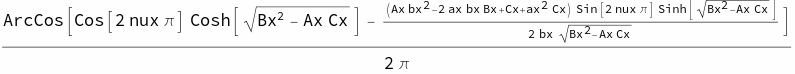

In [37]:
(* compute tune from the trace (exact) *)

ClearAll[nux1] ;
nux1 = nux1 /. (Solve[M1[[1, 1]] + M1[[2, 2]] == (M0[[1, 1]] + M0[[2, 2]] /. nux -> nux1), nux1] // Simplify // Last) /. C[1] -> 0

2                       2
      (Ax bx  - 2 ax bx Bx + Cx + ax  Cx) t
nux + ------------------------------------- - 
                     4 bx Pi
 
        2   4          2                      2
>   ((Ax  bx  - 2 Ax bx  (2 ax bx Bx + Cx - ax  Cx) + 
 
                2       2   2                          2    2    2
>        (1 + ax ) (4 bx  Bx  - 4 ax bx Bx Cx + (1 + ax ) Cx )) t  Cot[2 nux Pi]) / 
 
           2
>    (16 bx  Pi)
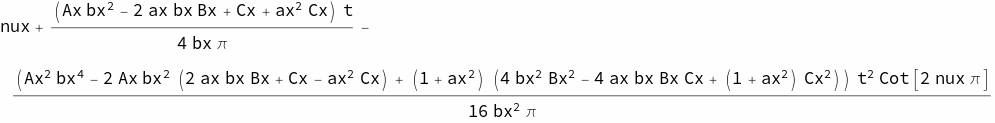

In [40]:
(* tune (series) *)

order = 1 + 1 ;

nux1$series = Collect[Simplify[Normal[Series[nux1 /. Thread[{Ax, Bx, Cx} -> t {Ax, Bx, Cx}], {t, 0, order}]], Assumptions -> 0 < nux < 1/2], t, Simplify] 

2
(2 ax Cosh[Sqrt[Bx  - Ax Cx]] Sin[2 nux Pi] + 
 
                                        2           2
>     ((2 bx Bx Cos[2 nux Pi] + (-(Ax bx ) + Cx + ax  Cx) Sin[2 nux Pi]) 
 
                     2                         2
>        Sinh[Sqrt[Bx  - Ax Cx]]) / (bx Sqrt[Bx  - Ax Cx])) / 
 
                                                2
>   (2 Sqrt[1 - Power[Cos[2 nux Pi] Cosh[Sqrt[Bx  - Ax Cx]] - 
 
                2                       2                               2
          (Ax bx  - 2 ax bx Bx + Cx + ax  Cx) Sin[2 nux Pi] Sinh[Sqrt[Bx  - Ax Cx]]
>         -------------------------------------------------------------------------, 2]])
                                               2
                                   2 bx Sqrt[Bx  - Ax Cx]
                2
(bx Cosh[Sqrt[Bx  - Ax Cx]] Sin[2 nux Pi] + 
 
                                                                        2
      (Cx Cos[2 nux Pi] + (-(bx Bx) + ax Cx) Sin[2 nux Pi]) Sinh[Sqrt[Bx  - Ax Cx]]
>     -----------------------------------------------------------------------------) / 
                                           2
                                    Sqrt[Bx  - Ax Cx]
 
                                             2
>   Sqrt[1 - Power[Cos[2 nux Pi] Cosh[Sqrt[Bx  - Ax Cx]] - 
 
              2                       2                               2
        (Ax bx  - 2 ax bx Bx + Cx + ax  Cx) Sin[2 nux Pi] Sinh[Sqrt[Bx  - Ax Cx]]
>       -------------------------------------------------------------------------, 2]]
                                             2
                                 2 bx Sqrt[Bx  - Ax Cx]
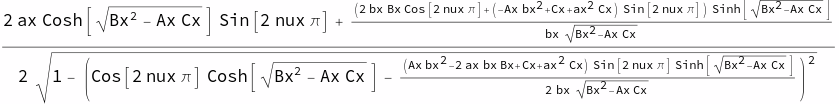
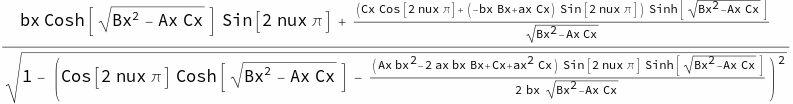

In [43]:
(* alpha and beta at the perturbation (exact) *)

ClearAll[ax1, bx1, ay1, by1] ;

M2 = CS[{ax1, bx1, nux1}, {ay1, by1, nuy1}] ;

ax1 = ax1 /. Solve[M2[[1, 1]] - M2[[2, 2]] == M1[[1, 1]] - M1[[2, 2]], ax1] // First // Simplify
bx1 = bx1 /. Solve[M2[[1, 2]] == M1[[1, 2]], bx1] // First // Simplify

In [48]:
(* alpha and beta at the perturbation (series) *)

order = 1 + 1 ;

ax1$series = Collect[Simplify[Normal[Series[ax1 /. Thread[{Ax, Bx, Cx} -> t {Ax, Bx, Cx}], {t, 0, order}]], Assumptions -> 0 < nux < 1/2], t, Simplify] ;
bx1$series = Collect[Simplify[Normal[Series[bx1 /. Thread[{Ax, Bx, Cx} -> t {Ax, Bx, Cx}], {t, 0, order}]], Assumptions -> 0 < nux < 1/2], t, Simplify] ;

2    2                               2    2
      2                (1 + ax ) qx        2                (1 + ay ) qy
{bx px  + 2 ax px qx + -------------, by py  + 2 ay py qy + -------------}
                            bx                                   by
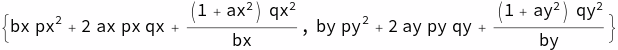

In [52]:
(* unperturbed invariants *)

{ix, iy} = List @@ I$CS / {2 Pi nux, 2 Pi nuy}

In [54]:
(* invariants (exact) *)

ix1 = ix /. {bx -> bx1, ax -> ax1} // Simplify ;
iy1 = iy /. {by -> by1, ay -> ay1} // Simplify ;

In [57]:
(* invariants (series) *)

order = 1 + 1 ;

ix1$series = Collect[Simplify[Normal[Series[ix1 /. Thread[{Ax, Bx, Cx} -> t {Ax, Bx, Cx}], {t, 0, order}]], Assumptions -> 0 < nux < 1/2], t, Simplify] ;
iy1$series = Collect[Simplify[Normal[Series[iy1 /. Thread[{Ay, By, Cy} -> t {Ay, By, Cy}], {t, 0, order}]], Assumptions -> 0 < nuy < 1/2], t, Simplify] ;

In [61]:
(* twiss transport *)
(* note, in the case of single perturbation, twiss parameters around the lattice can be obtained using unperturbed matrices *)

ClearAll[wx] ;
wx[{ax_, bx_}] := {{bx, -ax, 0, 0}, {-ax, (1 + ax^2)/bx, 0, 0}, {0, 0, 0, 0}, {0, 0, 0, 0}} ;

ClearAll[wy] ;
wy[{ay_, by_}] := {{0, 0, 0, 0}, {0, 0, 0, 0}, {0, 0, by, -ay}, {0, 0, -ay, (1 + ay^2)/by}} ;

Sqrt[bxs] (Cos[dmux] + ax Sin[dmux])
------------------------------------
              Sqrt[bx]
 


>    Sqrt[bx] Sqrt[bxs] Sin[dmux]
 


>    0
 


>    0

  (-ax + axs) Cos[dmux] + (1 + ax axs) Sin[dmux]
-(----------------------------------------------)
                Sqrt[bx] Sqrt[bxs]
 
     Sqrt[bx] (Cos[dmux] - axs Sin[dmux])
     ------------------------------------
>                 Sqrt[bxs]
 


>    0
 


>    0



0
 


>    0
 
     Sqrt[bys] (Cos[dmuy] + ay Sin[dmuy])
     ------------------------------------
>                  Sqrt[by]
 


>    Sqrt[by] Sqrt[bys] Sin[dmuy]



0
 


>    0
 
       (-ay + ays) Cos[dmuy] + (1 + ay ays) Sin[dmuy]
     -(----------------------------------------------)
>                    Sqrt[by] Sqrt[bys]
 
     Sqrt[by] (Cos[dmuy] - ays Sin[dmuy])
     ------------------------------------
>                 Sqrt[bys]
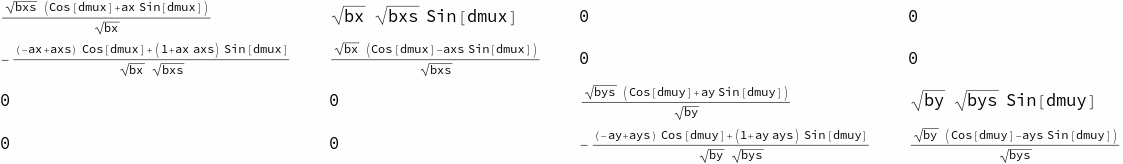

In [67]:
(* Transport matrix from location with {ax, bx, ay, by} to location with {axs, bxs, ays, bys} *)

M12 = normal[{axs, bxs}, {ays, bys}] . rotation[dmux, dmuy] . Inverse[normal[{ax, bx}, {ay, by}]] // Simplify ; 
M12 // TableForm

In [70]:
(* beta (exact) *)

bx1s = (M12 . M . wx[{ax1, bx1}] . Transpose[M] . Transpose[M12])[[1, 1]]  ;

In [72]:
(* beta (series) *)

order = 1 + 1 ;

bx1s$series = Collect[Simplify[Normal[Series[bx1s /. Thread[{Ax, Bx, Cx} -> t {Ax, Bx, Cx}], {t, 0, order}]], Assumptions -> 0 < nux < 1/2], t] ;

In [75]:
(* RMS beating (series) *)

bbx = ((bx1s$series  - bxs)/bxs /. t -> 1) // Simplify ;
bbx = (1/(2 Pi)) Integrate[bbx^2 /. dmux -> t, {t, 0, 2 Pi}] ;
bbx = bbx//ExpToTrig//TrigReduce//TrigFactor//Simplify//Expand//Simplify ;

In [79]:
(* transparency condition *)

condition = (Ax^2 bx^4 - 2 Ax bx^2 (2 ax bx Bx + Cx - ax^2 Cx) + (1 + ax^2)(4 bx^2 Bx^2 - 4 ax bx Bx Cx + (1 + ax^2) Cx^2)) == 0
Simplify[bbx, Assumptions -> condition]

2   4          2                      2
Ax  bx  - 2 Ax bx  (2 ax bx Bx + Cx - ax  Cx) + 
 
            2       2   2                          2    2
>    (1 + ax ) (4 bx  Bx  - 4 ax bx Bx Cx + (1 + ax ) Cx ) == 0
0

2                       2
      (Ax bx  - 2 ax bx Bx + Cx + ax  Cx) t
nux + -------------------------------------
                     4 bx Pi
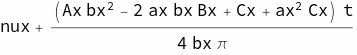

In [82]:
(* transparent tune *)

Collect[Simplify[nux1$series, Assumptions -> condition], t, Simplify]

In [84]:
(* leading order chromatic term isolation *)

S = {{0, 1}, {-1, 0}} ;
A = {{Ax,  Bx},  {Bx,  Cx}} ;
dA  = {{dAxdp, dBxdp}, {dBxdp, dCxdp}} ;

X = S . A ;
Y = S . dA dp ;
Z = Integrate[MatrixExp[-s X] . Y . MatrixExp[s X], {s, 0, 1}, Assumptions -> Element[s, Reals]] ;

B = - (S . Z) / dp // Simplify ;

In [92]:
Series[MatrixExp[X + dp Y] - MatrixExp[X] . MatrixExp[dp Z],  {dp, 0, 1}]

2       2         2       2
{{O[dp] , O[dp] }, {O[dp] , O[dp] }}

In [93]:
(* symmetric observation point *)

In [94]:
condition /. ax -> 0

2   4       2   2          2        2
Ax  bx  + 4 bx  Bx  - 2 Ax bx  Cx + Cx  == 0

2              2   4       2   2          2        2   2
      (Ax bx  + Cx) t   (Ax  bx  + 4 bx  Bx  - 2 Ax bx  Cx + Cx ) t  Cot[2 nux Pi]
nux + --------------- - ----------------------------------------------------------
          4 bx Pi                                    2
                                                16 bx  Pi
            2
      (Ax bx  + Cx) t
nux + ---------------
          4 bx Pi
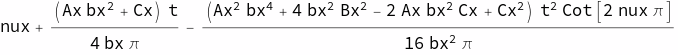
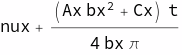

In [95]:
Collect[nux1$series /. ax -> 0, t, Simplify]
Collect[Simplify[nux1$series, Assumptions -> condition] /. ax -> 0, t, Simplify]

# Optics distortion (diagonal)

In [97]:
(* diagonal perturbation *)

diagonal = {Ax -> a, Bx -> 0, Cx -> b} ;

In [99]:
condition$diagonal = condition /. diagonal /. ax -> 0 // Simplify

2
b == a bx

2               2 2  2
      (b + a bx ) t   (b - a bx )  t  Cot[2 nux Pi]
nux + ------------- - -----------------------------
         4 bx Pi                     2
                                16 bx  Pi
        b t
nux + -------
      2 bx Pi
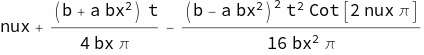
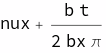

In [100]:
nux1$diagonal = Collect[nux1$series /. diagonal /. ax -> 0, t, Simplify]
Collect[Simplify[nux1$diagonal, Assumptions -> condition$diagonal], t, Simplify]

2         2    2   4   2
(b - a bx ) t   (-b  + a  bx ) t  Cot[2 nux Pi]
------------- + -------------------------------
    2 bx                         2
                             4 bx
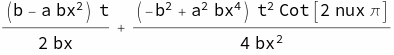

In [102]:
ax1$diagonal = Collect[ax1$series /. diagonal /. ax -> 0, t, FullSimplify]

2
     (b - a bx ) t Cot[2 nux Pi]
bx + --------------------------- - 
                  2
 
              2   2        2            2                              2
     (b - a bx ) t  (2 a bx  + (b + a bx ) Cos[4 nux Pi]) Csc[2 nux Pi]
>    -------------------------------------------------------------------
                                    8 bx
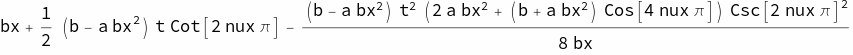

In [103]:
bx1$diagonal = Collect[bx1$series /. diagonal /. ax -> 0, t, FullSimplify]

2
      (b - a bx ) bxs t Cos[2 (mux - nux Pi)] Csc[2 nux Pi]
bxs + ----------------------------------------------------- + 
                              2 bx
 
               2       2           2
>   ((-b + a bx ) bxs t  (-b + a bx  + 
 
                  2                                                       2         2
>        (b + a bx ) (Cos[2 mux] + Cos[2 (mux - 2 nux Pi)])) Csc[2 nux Pi] ) / (8 bx )
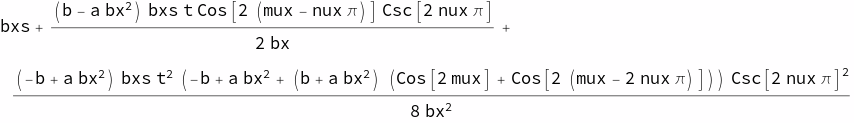

In [104]:
bx1s$diagonal = Collect[bx1s$series /. diagonal /. ax -> 0 /. dmux -> mux, t, FullSimplify]

2 2              4
((b - a bx )  Csc[2 nux Pi]  ((b + bx (-2 + a bx)) (b + bx (2 + a bx)) Cos[4 nux Pi] + 
 
            2       2    2   4                 2                           4
>       2 (b  + 2 bx  + a  bx  - 2 bx (b + a bx ) Sin[4 nux Pi]))) / (64 bx )
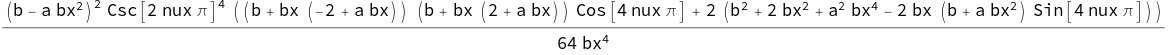

In [105]:
bbx$diagonal = Collect[bbx/. diagonal /. ax -> 0 /. dmux -> mux, t, FullSimplify]

# Optics distortion (potential)

In [106]:
(* diagonal potential ID model rules *)

rules = {
    a -> (kx*np)/(1 + dp) - (kx^2*lp*np*(-1 + np^2))/(6*(1 + dp)^3),
    b -> (kx*lp^2*np*(-1 + np^2))/(12*(1 + dp)^3) + (kx^2*lp^3*np*(-1 + np^4))/(120*(1 + dp)^5),
    c -> (ky*np)/(1 + dp) - (ky^2*lp*np*(-1 + np^2))/(6*(1 + dp)^3),
    d -> (ky*lp^2*np*(-1 + np^2))/(12*(1 + dp)^3) + (ky^2*lp^3*np*(-1 + np^4))/(120*(1 + dp)^5)
} ;

In [108]:
order = 1 + 1 ;

nux1$id = nux1$diagonal /. rules ;
nux1$id = Collect[Normal[Series[nux1$id /. t -> 1 /. kx -> t kx, {t, 0, order}]], t, Simplify] ;

48 bx dnux Pi
----------------------------
         2     2         2
np (12 bx  + lp  (-1 + np ))
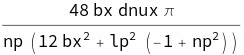

In [111]:
(* 1st order relation between focusing and tune shift *)
(* note, given a tune shift it should be possible to compute kx or ky *)

kx /. Solve[dnux == (nux1$id - nux) /. dp -> 0 /. t^2 -> 0 /. t -> 1, kx] // First // Simplify

# Optics distortion (twiss and distribution transformation)

In [114]:
ClearAll[idtm] ;
idtm::usage = "idtm[{kx, ky}, np, lp, dp] -- compute id thin insertion exponent diagonal and corresponding transport matrix (second order in kx and kz)" ;
idtm[                         (* -- id thin insertion diagonal and transport matrix *)
	{kx_, ky_},               (* -- focusing strength (1/m) *)
	count_,                   (* -- total number of (super) periods *)
	period_,                  (* -- (super) period length (m) *)
	delta_                    (* -- energy delta *)
] := Block[
	{a, b, c, d, diagonal, matrix},
	a = (kx*count)/(1 + delta) - (kx^2*period*count*(-1 + count^2))/(6*(1 + delta)^3) ;
	b = (kx*period^2*count*(-1 + count^2))/(12*(1 + delta)^3) + (kx^2*period^3*count*(-1 + count^4))/(120*(1 + delta)^5) ;
	c = (ky*count)/(1 + delta) - (ky^2*period*count*(-1 + count^2))/(6*(1 + delta)^3); 
	d = (ky*period^2*count*(-1 + count^2))/(12*(1 + delta)^3) + (ky^2*period^3*count*(-1 + count^4))/(120*(1 + delta)^5) ;
	diagonal = {a, b, c, d} ;
	matrix = MatrixExp[{{0, 1, 0, 0}, {-1, 0, 0, 0}, {0, 0, 0, 1}, {0, 0, -1, 0}} . DiagonalMatrix[diagonal]] ;
	{diagonal, matrix}   
] ;

In [117]:
order = 1 ;

MK = Normal[Series[Last[idtm[{t kx, t ky}, np, lp, 0]], {t, 0, order}]] /. t -> 1 ;
MD = {{1, np lp/2, 0, 0}, {0, 1, 0, 0}, {0, 0, 1, np lp/2}, {0, 0, 0, 1}} ;
M =  MD . MK . MD ;

2    2   2
                  (1 + ax ) lp  np
bx - 2 ax lp np + ----------------- + 
                         bx
 
                                2    2             2
                         (1 + ax ) lp  np (1 + 2 np )                  2
    kx lp np (-6 bx np - ---------------------------- + ax lp (1 + 8 np )) t
                                      bx
>   ------------------------------------------------------------------------
                                       6
 
                                                                  2    2          2
                                                           (1 + ax ) lp  (1 + 8 np )
                  2          kx np (-12 bx + 24 ax lp np - -------------------------) t
           (1 + ax ) lp np                                            bx
     -ax + --------------- + ----------------------------------------------------------
>                bx                                      12
 





>       0   0

                                                             2    2          2
                                                      (1 + ax ) lp  (1 + 8 np )
             2          kx np (-12 bx + 24 ax lp np - -------------------------) t
      (1 + ax ) lp np                                            bx
-ax + --------------- + ----------------------------------------------------------
            bx                                      12
 
>    
 


           2                               2
     1 + ax    kx np (-2 ax bx + lp np + ax  lp np) t
     ------- - --------------------------------------
>      bx                        bx
 





>       0   0

0   0
 
>       0   0

0   0
 
>       0   0
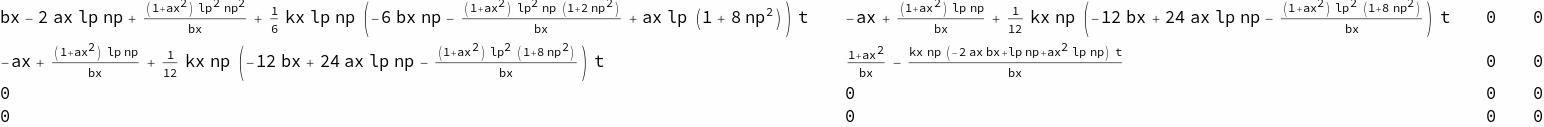

In [121]:
Collect[Series[(M . wx[{ax, bx}] . Transpose[M]) /. kx -> t kx /. ax -> ax, {kx, 0, order}]  // Normal // Simplify, kx, Simplify] // TableForm

# Perturbation factorization

$\hat M = M \prod_i \exp(S \hat A_i) = M \exp(\varepsilon \hat A^{(1)} + \varepsilon^2 \hat A^{(2)} + \dots)$

$S \hat A^{(1)} = S \sum_i \hat A_i$

$S \hat A^{(2)} = \sum_{i \ge j} \frac{1}{1 + \delta_{i, j}} \frac{1}{2} \{ S \hat A_i, S \hat A_j \} = S \sum_{i \ge j} \frac{1}{1 + \delta_{i, j}} \frac{1}{2} (\hat A_i S \hat A_j - \hat A_j S \hat A_i)$

$S \hat A^{(3)}=\sum_{i \ge j \ge k} \frac{1}{1+\delta_{ij}} \frac{1}{1+\delta_{ik}+\delta_{jk}} (\frac{1}{4} \{\{S\hat A_i,S\hat A_j\},S\hat A_k\}-\frac{1}{12}\{\{S\hat A_i,S\hat A_k\},S\hat A_j\}-\frac{1}{12}\{\{S\hat A_j,S\hat A_k\},S\hat A_i\})$

$
S\hat A^{(4)} =
\sum_{i \ge j \ge k \ge l}
\frac{1}{1+\delta_{ij}}\;
\frac{1}{1+\delta_{ik}+\delta_{jk}}\;
\frac{1}{1+\delta_{il}+\delta_{jl}+\delta_{kl}}
\frac{1}{12} (
\{\{\{S \hat A_i,S \hat A_j\},S \hat A_k\},S \hat A_l\}
+\{S \hat A_i,\{\{S \hat A_j,S \hat A_k\},S \hat A_l\}\}
+\{S \hat A_i,\{S \hat A_j,\{S \hat A_k,S \hat A_l\}\}\}
+\{S \hat A_j,\{S \hat A_k,\{S \hat A_l,S \hat A_i\}\}\}
)
$